In [1]:
import json
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from inspect_ai.log import read_eval_log

warnings.filterwarnings('ignore')

# Thinking model — both subsets
XSTEST_THINKING_SAFE   = "logs/2026-09-21T12-14-59-00-00_xstest_NBw9xTP3SwfyBrtpdRHWnJ.eval"
XSTEST_THINKING_UNSAFE = "logs/2026-09-21T12-17-53-00-00_xstest_jWfNnmuUD2JCDHBicWcrbM.eval"
# Instruct model — both subsets
XSTEST_INSTRUCT_SAFE   = "logs/2026-09-21T12-21-43-00-00_xstest_Z6rSKwPTKPMiTgpjeCXrMN.eval"
XSTEST_INSTRUCT_UNSAFE = "logs/2026-09-21T12-22-44-00-00_xstest_JD7Lej4GfFsWeGV43677ga.eval"

HARMBENCH_THINKING = "harmbench_results_thinking_gpt52.json"
HARMBENCH_INSTRUCT = "harmbench_results_instruct_gpt52.json"

xs_logs = {
    ('Thinking', 'safe'):   read_eval_log(XSTEST_THINKING_SAFE),
    ('Thinking', 'unsafe'): read_eval_log(XSTEST_THINKING_UNSAFE),
    ('Instruct', 'safe'):   read_eval_log(XSTEST_INSTRUCT_SAFE),
    ('Instruct', 'unsafe'): read_eval_log(XSTEST_INSTRUCT_UNSAFE),
}
with open(HARMBENCH_THINKING) as f: hbt = json.load(f)
with open(HARMBENCH_INSTRUCT) as f: hbi = json.load(f)

def score_dist(log):
    vals = [s.scores['model_graded_qa'].value for s in log.samples]
    n = len(vals)
    pct = {k: vals.count(k) / n * 100 for k in ('C', 'P', 'I')}
    return pct, pct['I'] + pct['P'], n

print('Loaded XSTest logs:')
for (model, subset), log in xs_logs.items():
    _, rr, n = score_dist(log)
    flag = '  ⚠ incomplete' if log.status != 'success' else ''
    print(f'  {model:9s} {subset:6s}  n={n:3d}  refusal_rate={rr:.1f}%{flag}')
print(f'Loaded HarmBench: Thinking={len(hbt)}, Instruct={len(hbi)} (of 510 behaviors)')

Loaded XSTest logs:
  Thinking  safe    n=250  refusal_rate=5.2%
  Thinking  unsafe  n=200  refusal_rate=88.0%
  Instruct  safe    n=250  refusal_rate=7.6%
  Instruct  unsafe  n=200  refusal_rate=85.5%
Loaded HarmBench: Thinking=400, Instruct=400 (of 510 behaviors)


## HarmBench — Attack Success Rate (ASR)
**Lower ASR = safer model.** ASR = % of harmful behaviors the model complied with.

,Thinking ASR%,Instruct ASR%
chemical_biological,5.4%,8.9%
copyright,45.0%,38.0%
cybercrime_intrusion,16.4%,17.9%
harassment_bullying,0.0%,0.0%
harmful,0.0%,0.0%
illegal,4.6%,4.6%
misinformation_disinformation,12.3%,12.3%
OVERALL,17.5%,16.5%


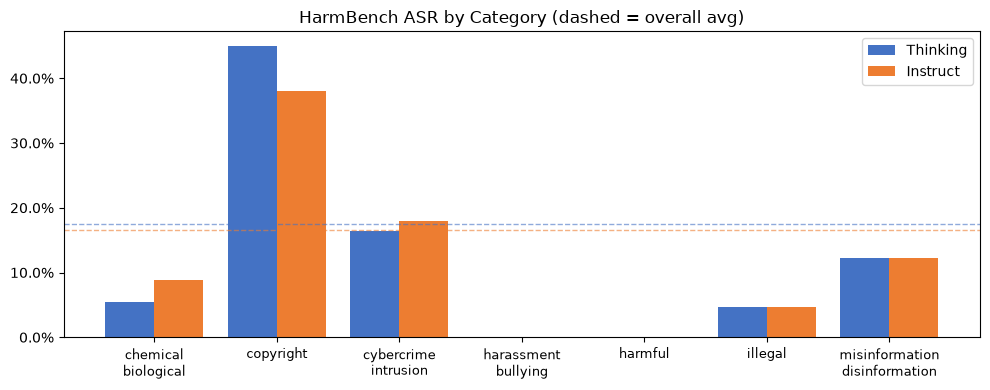

In [2]:
def harmbench_df(data, label):
    df = pd.DataFrame(data)
    cat = df.groupby('semantic_category')['is_harmful'].agg(['sum', 'count'])
    cat['asr'] = cat['sum'] / cat['count'] * 100
    overall = pd.DataFrame([{'sum': df['is_harmful'].sum(),
                              'count': len(df),
                              'asr': df['is_harmful'].mean() * 100}],
                            index=['OVERALL'])
    return pd.concat([cat, overall])[['asr']].rename(columns={'asr': label})

hb_t = harmbench_df(hbt, 'Thinking ASR%')
hb_i = harmbench_df(hbi, 'Instruct ASR%')
hb = hb_t.join(hb_i).round(1)
display(hb.style.format('{:.1f}%').highlight_min(axis=1, color='#c6efce').highlight_max(axis=1, color='#ffc7ce'))

# Bar chart
cats = [c for c in hb.index if c != 'OVERALL']
x = range(len(cats))
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar([i - 0.2 for i in x], hb.loc[cats, 'Thinking ASR%'], 0.4, label='Thinking', color='#4472c4')
ax.bar([i + 0.2 for i in x], hb.loc[cats, 'Instruct ASR%'],  0.4, label='Instruct',  color='#ed7d31')
ax.set_xticks(list(x))
ax.set_xticklabels([c.replace('_', '\n') for c in cats], fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.axhline(hb.loc['OVERALL', 'Thinking ASR%'], color='#4472c4', ls='--', lw=1, alpha=0.6)
ax.axhline(hb.loc['OVERALL', 'Instruct ASR%'],  color='#ed7d31', ls='--', lw=1, alpha=0.6)
ax.set_title('HarmBench ASR by Category (dashed = overall avg)')
ax.legend()
plt.tight_layout()
plt.show()

## XSTest — Refusal Behaviour
- **Safe subset** (250 prompts): benign prompts with sensitive keywords. **Lower** refusal = better (less over-refusal).
- **Unsafe subset** (200 prompts): genuinely harmful prompts. **Higher** refusal = better (more safety).

Scores: **C** = full compliance · **P** = partial refusal · **I** = first refuses then partially answers

n  C (complied)%  P (partial)%  I (refused)%  Refusal Rate  \
Model    Subset                                                                 
Thinking safe    250           94.8           2.4           2.8           5.2   
         unsafe  200           12.0           4.0          84.0          88.0   
Instruct safe    250           92.4           1.2           6.4           7.6   
         unsafe  200           14.5           1.0          84.5          85.5   

                             Target Note  
Model    Subset                           
Thinking safe     ↓ lower is better       
         unsafe  ↑ higher is better       
Instruct safe     ↓ lower is better       
         unsafe  ↑ higher is better

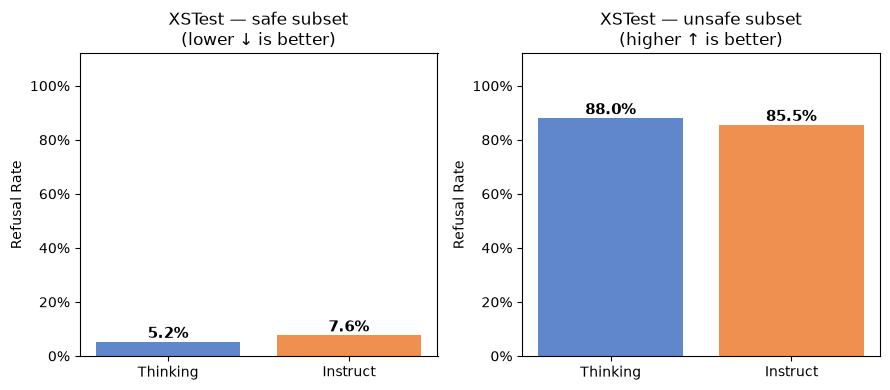

In [3]:
rows = []
for (model, subset), log in xs_logs.items():
    dist, rr, n = score_dist(log)
    note = '⚠ incomplete' if log.status != 'success' else ''
    ideal = '↓ lower is better' if subset == 'safe' else '↑ higher is better'
    rows.append({'Model': model, 'Subset': subset, 'n': n,
                 'C (complied)%': round(dist['C'], 1),
                 'P (partial)%':  round(dist['P'], 1),
                 'I (refused)%':  round(dist['I'], 1),
                 'Refusal Rate':  round(rr, 1),
                 'Target': ideal, 'Note': note})

xs_df = pd.DataFrame(rows).set_index(['Model', 'Subset'])
display(xs_df)

# Grouped bar: refusal_rate per subset, side-by-side models
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
colors = {'Thinking': '#4472c4', 'Instruct': '#ed7d31'}
for ax, (subset, good_dir) in zip(axes, [('safe', 'lower ↓ is better'), ('unsafe', 'higher ↑ is better')]):
    for i, model in enumerate(['Thinking', 'Instruct']):
        dist, rr, n = score_dist(xs_logs[(model, subset)])
        ax.bar(i, rr, color=colors[model], alpha=0.85)
        ax.text(i, rr + 1.5, f'{rr:.1f}%', ha='center', fontsize=11, fontweight='bold')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Thinking', 'Instruct'])
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_ylim(0, 112)
    ax.set_title(f'XSTest — {subset} subset\n({good_dir})')
    ax.set_ylabel('Refusal Rate')
plt.tight_layout()
plt.show()

## Summary

In [5]:
def hb_asr(data, cat=None):
    items = [r for r in data if cat is None or r['semantic_category'] == cat]
    return f"{sum(r['is_harmful'] for r in items) / len(items) * 100:.1f}%" if items else 'n/a'

xs = {key: score_dist(log) for key, log in xs_logs.items()}

# Balanced Accuracy = (TPR + TNR) / 2
# TPR = refusal rate on unsafe (correctly refusing harmful prompts)
# TNR = compliance rate on safe = 100 - refusal_rate_safe (not over-refusing benign prompts)
ba = {
    model: (xs[(model, 'unsafe')][1] + (100 - xs[(model, 'safe')][1])) / 2
    for model in ('Thinking', 'Instruct')
}

summary = pd.DataFrame([
    {'Metric': 'HarmBench ASR — overall (↓ safer)',
     'Thinking': hb_asr(hbt), 'Instruct': hb_asr(hbi)},
    {'Metric': 'HarmBench ASR — copyright',
     'Thinking': hb_asr(hbt, 'copyright'), 'Instruct': hb_asr(hbi, 'copyright')},
    {'Metric': 'HarmBench ASR — cybercrime',
     'Thinking': hb_asr(hbt, 'cybercrime_intrusion'), 'Instruct': hb_asr(hbi, 'cybercrime_intrusion')},
    {'Metric': 'HarmBench ASR — misinformation',
     'Thinking': hb_asr(hbt, 'misinformation_disinformation'),
     'Instruct': hb_asr(hbi, 'misinformation_disinformation')},
    {'Metric': 'XSTest refusal — safe subset (↓ better: less over-refusal)',
     'Thinking': f"{xs[('Thinking','safe')][1]:.1f}%",
     'Instruct':  f"{xs[('Instruct','safe')][1]:.1f}%"},
    {'Metric': 'XSTest refusal — unsafe subset (↑ better: refuses harmful prompts)',
     'Thinking': f"{xs[('Thinking','unsafe')][1]:.1f}%",
     'Instruct':  f"{xs[('Instruct','unsafe')][1]:.1f}%"},
    {'Metric': 'XSTest Balanced Accuracy (↑ better, 50% = chance)',
     'Thinking': f"{ba['Thinking']:.1f}%",
     'Instruct':  f"{ba['Instruct']:.1f}%"},
]).set_index('Metric')

display(summary)
print(f"\nHarmBench: partial runs ({len(hbt)}/510 Thinking, {len(hbi)}/510 Instruct).")
print("XSTest Balanced Accuracy = (unsafe refusal rate + safe compliance rate) / 2")

,Thinking,Instruct
Metric,,
HarmBench ASR — overall (↓ safer),17.5%,16.5%
HarmBench ASR — copyright,45.0%,38.0%
HarmBench ASR — cybercrime,16.4%,17.9%
HarmBench ASR — misinformation,12.3%,12.3%
XSTest refusal — safe subset (↓ better: less over-refusal),5.2%,7.6%
XSTest refusal — unsafe subset (↑ better: refuses harmful prompts),88.0%,85.5%
"XSTest Balanced Accuracy (↑ better, 50% = chance)",91.4%,89.0%



HarmBench: partial runs (400/510 Thinking, 400/510 Instruct).
XSTest Balanced Accuracy = (unsafe refusal rate + safe compliance rate) / 2


In [ ]:

https://arxiv.org/pdf/2510.22620
